# 08 - Transformer Baseline (Indic-BERT)

Fine-tunes **XLM-RoBERTa-base** on the **exact frozen split** saved in `data/splits/`,
so the comparison against the statistical baseline is like-for-like.

**Why this notebook exists.** Dr Hunter's point in the 5 August meeting was that the
statistical baseline separates the two classes weakly: not-hate F1 around 0.73 against
hate F1 around 0.56, with a confusion matrix that shows no decisive split. His
prediction was that a pretrained model would do better. This notebook tests that
prediction on identical data.

**Protocol lock.** Same 3,659 train / 915 test rows, same `random_state=42`, same
metrics function shape as `hinglish_hate.baseline.full_metrics`. Nothing about the
data changes; only the model does.

**Runtime > Change runtime type > T4 GPU** before running. Roughly 8-12 minutes end to end.

### 1. Setup

In [1]:
import subprocess, sys
try:
    import transformers, torch
    print('transformers', transformers.__version__, '| torch', torch.__version__)
except ImportError:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'transformers', 'torch'])
    import transformers, torch
    print('installed transformers', transformers.__version__)

transformers 5.16.1 | torch 2.11.0+cu128


In [2]:
try:
    from google.colab import drive; drive.mount('/content/drive')
except Exception as e:
    print('Not on Colab / already mounted:', e)

Mounted at /content/drive


In [3]:
import numpy as np, pandas as pd, torch, time
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from sklearn.metrics import (f1_score, accuracy_score, classification_report,
                             confusion_matrix, precision_recall_fscore_support)

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', DEVICE)
if DEVICE == 'cpu':
    print('WARNING: no GPU. Runtime > Change runtime type > T4 GPU, then re-run.')

device: cuda


### 2. Load the frozen split

These are the same rows the statistical baseline was scored on. Loading them rather than
re-splitting is what makes the comparison valid.

In [4]:
from pathlib import Path

PROJECT_ROOT = Path('/content/drive/MyDrive/dissertation') # Changed from Path.cwd().parent
DATA_ROOT = PROJECT_ROOT / 'data'
SPLITS    = DATA_ROOT / 'splits'
FIG_DIR   = Path('/content/drive/MyDrive/dissertation/writing/figures'); FIG_DIR.mkdir(parents=True, exist_ok=True)

train_df = pd.read_parquet(SPLITS / 'bohra_train.parquet')
test_df  = pd.read_parquet(SPLITS / 'bohra_test.parquet')

print(f'train {len(train_df)} (hate {train_df["label"].mean():.3f})')
print(f'test  {len(test_df)} (hate {test_df["label"].mean():.3f})')
assert len(train_df) == 3659 and len(test_df) == 915, 'split changed - comparison would not be like-for-like'
print('split matches the statistical baseline')

train 3659 (hate 0.363)
test  915 (hate 0.363)
split matches the statistical baseline


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 3. Model and tokenizer

`xlm-roberta-base` is a multilingual encoder pretrained on 100 languages including
romanised text. Its tokenizer is **SentencePiece subword**, which is the key difference
from TF-IDF: `chutiya` and `chuteeya` become overlapping subword pieces rather than two
unrelated vocabulary entries, so a spelling variant is not automatically an unknown word.

To swap models later, change `MODEL_NAME` only. Everything below is model-agnostic:
- `google/muril-base-cased` - pretrained on Indian languages *and* transliterated Roman text
- `ai4bharat/indic-bert` - lighter ALBERT-based Indian-language model

### Hugging Face Login

To access gated models on Hugging Face, you need to log in. You can generate an access token from your Hugging Face settings page (usually found under 'Access Tokens').

In [6]:
!pip install -U transformers

from huggingface_hub import notebook_login

notebook_login()

# Load model directly
from transformers import AutoModel
model = AutoModel.from_pretrained("ai4bharat/indic-bert", device_map="auto")

config.json:   0%|          | 0.00/507 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  135MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/25 [00:00<?, ?it/s]

[transformers] AlbertModel LOAD REPORT from: ai4bharat/indic-bert
Key                              | Status     |  | 
---------------------------------+------------+--+-
predictions.dense.weight         | UNEXPECTED |  | 
predictions.decoder.bias         | UNEXPECTED |  | 
predictions.bias                 | UNEXPECTED |  | 
predictions.LayerNorm.bias       | UNEXPECTED |  | 
sop_classifier.classifier.bias   | UNEXPECTED |  | 
sop_classifier.classifier.weight | UNEXPECTED |  | 
predictions.LayerNorm.weight     | UNEXPECTED |  | 
predictions.dense.bias           | UNEXPECTED |  | 
predictions.decoder.weight       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [7]:
MODEL_NAME = 'ai4bharat/indic-bert'
MAX_LEN    = 128     # posts are short; 128 subword tokens covers almost all of them
BATCH_SIZE = 16
EPOCHS     = 25
LR         = 2e-5

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print('tokenizer loaded:', MODEL_NAME)

# sanity check the romanisation point
for w in ['chutiya', 'chuteeya', 'kutta', 'kuttaa']:
    print(f'  {w:10s} -> {tokenizer.tokenize(w)}')

model.safetensors: reconstructing file:   0%|          |  0.00B /  135MB            

model.safetensors: downloading bytes:           |  0.00B            

spiece.model:   0%|          | 0.00/5.65M [00:00<?, ?B/s]

tokenizer loaded: ai4bharat/indic-bert
  chutiya    -> ['▁chu', 'tiya']
  chuteeya   -> ['▁chu', 'te', 'e', 'ya']
  kutta      -> ['▁k', 'utta']
  kuttaa     -> ['▁k', 'utta', 'a']


In [8]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print('tokenizer loaded:', MODEL_NAME)

# sanity check the romanisation point
for w in ['chutiya', 'chuteeya', 'kutta', 'kuttaa']:
    print(f'  {w:10s} -> {tokenizer.tokenize(w)}')


tokenizer loaded: ai4bharat/indic-bert
  chutiya    -> ['▁chu', 'tiya']
  chuteeya   -> ['▁chu', 'te', 'e', 'ya']
  kutta      -> ['▁k', 'utta']
  kuttaa     -> ['▁k', 'utta', 'a']


### 4. Dataset and dataloaders

In [9]:
class PostDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = list(texts); self.labels = list(labels)
        self.tok = tokenizer; self.max_len = max_len
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, i):
        enc = self.tok(str(self.texts[i]), truncation=True, padding='max_length',
                       max_length=self.max_len, return_tensors='pt')
        return {'input_ids': enc['input_ids'].squeeze(0),
                'attention_mask': enc['attention_mask'].squeeze(0),
                'labels': torch.tensor(self.labels[i], dtype=torch.long)}

train_ds = PostDataset(train_df['text'], train_df['label'], tokenizer, MAX_LEN)
test_ds  = PostDataset(test_df['text'],  test_df['label'],  tokenizer, MAX_LEN)
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE*2, shuffle=False)
print(f'{len(train_dl)} train batches, {len(test_dl)} test batches')

229 train batches, 29 test batches


### 5. Class weighting

The statistical baseline used `class_weight='balanced'`. To keep the comparison honest the
transformer gets the same correction, applied as weights inside the loss function rather
than as a scikit-learn argument. Same idea, different mechanism: errors on the rarer hate
class are penalised more heavily.

In [10]:
counts = np.bincount(train_df['label'].values)
weights = torch.tensor(len(train_df) / (2.0 * counts), dtype=torch.float).to(DEVICE)
print(f'class counts: not={counts[0]}, hate={counts[1]}')
print(f'loss weights: not={weights[0]:.3f}, hate={weights[1]:.3f}')

class counts: not=2331, hate=1328
loss weights: not=0.785, hate=1.378


### 6. Train

A visible loop rather than the `Trainer` API, for the same reason `stratified_kfold_evaluate`
is a visible loop: every step can be explained in the viva, and it does not break when the
`transformers` version changes.

Each step: forward pass, weighted cross-entropy loss, backward pass, gradient clip, optimiser
step, scheduler step, zero the gradients.

In [11]:
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2).to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total_steps = len(train_dl) * EPOCHS
scheduler = get_linear_schedule_with_warmup(optimizer, int(0.1 * total_steps), total_steps)
loss_fn = torch.nn.CrossEntropyLoss(weight=weights)

t0 = time.time()
for epoch in range(1, EPOCHS + 1):
    model.train(); running = 0.0
    for step, batch in enumerate(train_dl, 1):
        ids  = batch['input_ids'].to(DEVICE)
        mask = batch['attention_mask'].to(DEVICE)
        y    = batch['labels'].to(DEVICE)

        logits = model(input_ids=ids, attention_mask=mask).logits
        loss   = loss_fn(logits, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step(); scheduler.step(); optimizer.zero_grad()

        running += loss.item()
        if step % 50 == 0:
            print(f'  epoch {epoch} step {step}/{len(train_dl)}  loss {running/step:.4f}')
    print(f'epoch {epoch}/{EPOCHS} done | mean loss {running/len(train_dl):.4f} | {time.time()-t0:.0f}s elapsed')
print(f'\ntraining finished in {time.time()-t0:.0f}s')

Loading weights:   0%|          | 0/25 [00:00<?, ?it/s]

[transformers] AlbertForSequenceClassification LOAD REPORT from: ai4bharat/indic-bert
Key                              | Status     | 
---------------------------------+------------+-
predictions.dense.weight         | UNEXPECTED | 
predictions.decoder.bias         | UNEXPECTED | 
predictions.bias                 | UNEXPECTED | 
predictions.LayerNorm.bias       | UNEXPECTED | 
sop_classifier.classifier.bias   | UNEXPECTED | 
sop_classifier.classifier.weight | UNEXPECTED | 
predictions.LayerNorm.weight     | UNEXPECTED | 
predictions.dense.bias           | UNEXPECTED | 
predictions.decoder.weight       | UNEXPECTED | 
classifier.bias                  | MISSING    | 
classifier.weight                | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  epoch 1 step 50/229  loss 0.6926
  epoch 1 step 100/229  loss 0.6929
  epoch 1 step 150/229  loss 0.6929
  epoch 1 step 200/229  loss 0.6929
epoch 1/25 done | mean loss 0.6927 | 71s elapsed
  epoch 2 step 50/229  loss 0.6731
  epoch 2 step 100/229  loss 0.6569
  epoch 2 step 150/229  loss 0.6568
  epoch 2 step 200/229  loss 0.6509
epoch 2/25 done | mean loss 0.6497 | 144s elapsed
  epoch 3 step 50/229  loss 0.6297
  epoch 3 step 100/229  loss 0.6245
  epoch 3 step 150/229  loss 0.6334
  epoch 3 step 200/229  loss 0.6285
epoch 3/25 done | mean loss 0.6252 | 219s elapsed
  epoch 4 step 50/229  loss 0.6317
  epoch 4 step 100/229  loss 0.6226
  epoch 4 step 150/229  loss 0.6217
  epoch 4 step 200/229  loss 0.6205
epoch 4/25 done | mean loss 0.6171 | 293s elapsed
  epoch 5 step 50/229  loss 0.5943
  epoch 5 step 100/229  loss 0.6029
  epoch 5 step 150/229  loss 0.6164
  epoch 5 step 200/229  loss 0.6122
epoch 5/25 done | mean loss 0.6088 | 368s elapsed
  epoch 6 step 50/229  loss 0.5826
 

### 7. Evaluate on the frozen test set

In [12]:
model.eval(); preds, trues = [], []
with torch.no_grad():
    for batch in test_dl:
        logits = model(input_ids=batch['input_ids'].to(DEVICE),
                       attention_mask=batch['attention_mask'].to(DEVICE)).logits
        preds.extend(logits.argmax(dim=1).cpu().numpy())
        trues.extend(batch['labels'].numpy())

p, r, f, s = precision_recall_fscore_support(trues, preds, zero_division=0)
res = {
    'model': MODEL_NAME,
    'macro_f1': f1_score(trues, preds, average='macro'),
    'hate_f1':  f1_score(trues, preds, pos_label=1, zero_division=0),
    'accuracy': accuracy_score(trues, preds),
    'precision_not': p[0], 'recall_not': r[0], 'f1_not': f[0],
    'precision_hate': p[1], 'recall_hate': r[1], 'f1_hate': f[1],
}
print(f"macro-F1 = {res['macro_f1']:.3f}   hate-F1 = {res['hate_f1']:.3f}   acc = {res['accuracy']:.3f}")
print()
print(classification_report(trues, preds, target_names=['not','hate'], digits=3, zero_division=0))

macro-F1 = 0.620   hate-F1 = 0.493   acc = 0.662

              precision    recall  f1-score   support

         not      0.715     0.782     0.747       583
        hate      0.542     0.452     0.493       332

    accuracy                          0.662       915
   macro avg      0.628     0.617     0.620       915
weighted avg      0.652     0.662     0.655       915



### 8. Confusion matrix

Put this next to the baseline confusion matrix from notebook 06. Hunter's specific concern
was that the baseline matrix showed no decisive separation; this is the direct comparison.

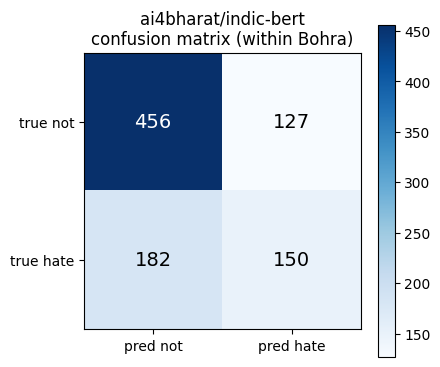

confusion matrix:
 [[456 127]
 [182 150]]


In [13]:
import matplotlib.pyplot as plt
cm = confusion_matrix(trues, preds)
fig, ax = plt.subplots(figsize=(4.5,4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0,1], ['pred not','pred hate']); ax.set_yticks([0,1], ['true not','true hate'])
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i,j], ha='center', va='center',
                color='white' if cm[i,j] > cm.max()/2 else 'black', fontsize=14)
ax.set_title(f'{MODEL_NAME}\nconfusion matrix (within Bohra)')
plt.colorbar(im); plt.tight_layout()
plt.savefig(FIG_DIR / f'confusion_{MODEL_NAME.replace("/","_")}.png', dpi=150, bbox_inches='tight')
plt.show()
print('confusion matrix:\n', cm)

### 9. Cross-dataset test (Objective 3)

The generalisation question, on the transformer this time. Train stays as-is; only the test
set changes to HASOC. This is the number that matters most for the dissertation's argument.

In [14]:
import sys; sys.path.insert(0, '/content/drive/MyDrive/dissertation/notebooks')
from hinglish_hate import load_hasoc2022_threads, load_hasoc2021, filter_romanised

h22   = load_hasoc2022_threads(DATA_ROOT)
h22_r = filter_romanised(h22, include_mixed=True)
print(f'HASOC22 romanised: {len(h22_r)} rows, hate rate {h22_r["label"].mean():.3f}')

cross_dl = DataLoader(PostDataset(h22_r['text'], h22_r['label'], tokenizer, MAX_LEN),
                      batch_size=BATCH_SIZE*2, shuffle=False)
model.eval(); cpreds, ctrues = [], []
with torch.no_grad():
    for batch in cross_dl:
        logits = model(input_ids=batch['input_ids'].to(DEVICE),
                       attention_mask=batch['attention_mask'].to(DEVICE)).logits
        cpreds.extend(logits.argmax(dim=1).cpu().numpy())
        ctrues.extend(batch['labels'].numpy())

cross_macro = f1_score(ctrues, cpreds, average='macro')
cross_hate  = f1_score(ctrues, cpreds, pos_label=1, zero_division=0)
print(f'\nBohra -> HASOC22:  macro-F1 = {cross_macro:.3f}   hate-F1 = {cross_hate:.3f}')
print(f'DROP from within-dataset: {res["macro_f1"] - cross_macro:.3f} macro-F1')

HASOC22 romanised: 4306 rows, hate rate 0.513

Bohra -> HASOC22:  macro-F1 = 0.366   hate-F1 = 0.080
DROP from within-dataset: 0.254 macro-F1


### 10. Save results and the model

In [15]:
W = Path('/content/drive/MyDrive/dissertation/writing'); W.mkdir(parents=True, exist_ok=True)
row = {**res, 'cross_hasoc22_macro_f1': cross_macro, 'cross_hasoc22_hate_f1': cross_hate,
       'epochs': EPOCHS, 'lr': LR, 'batch_size': BATCH_SIZE, 'max_len': MAX_LEN}

out_csv = W / 'transformer_results.csv'
existing = pd.read_csv(out_csv) if out_csv.exists() else pd.DataFrame()
pd.concat([existing, pd.DataFrame([row])], ignore_index=True).to_csv(out_csv, index=False)
print('appended to', out_csv)
display(pd.DataFrame([row]).round(3))

SAVE = Path('/content/drive/MyDrive/dissertation/models') / MODEL_NAME.replace('/','_')
SAVE.mkdir(parents=True, exist_ok=True)
model.save_pretrained(SAVE); tokenizer.save_pretrained(SAVE)
print('model saved ->', SAVE)

appended to /content/drive/MyDrive/dissertation/writing/transformer_results.csv


,model,macro_f1,hate_f1,accuracy,precision_not,recall_not,f1_not,precision_hate,recall_hate,f1_hate,cross_hasoc22_macro_f1,cross_hasoc22_hate_f1,epochs,lr,batch_size,max_len
0,ai4bharat/indic-bert,0.62,0.493,0.662,0.715,0.782,0.747,0.542,0.452,0.493,0.366,0.08,25,0.0,16,128


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

model saved -> /content/drive/MyDrive/dissertation/models/ai4bharat_indic-bert


### 11. Comparison table

The one artefact to have on screen tomorrow. Baseline numbers are the locked figures from
notebook 06/07; replace them if you re-lock the baseline.

,model,within_macro_f1,within_hate_f1,within_f1_not,cross_h22_macro_f1
0,TF-IDF+LogReg (single split),0.642,0.555,0.729,0.510
1,ai4bharat/indic-bert,0.620,0.493,0.747,0.366


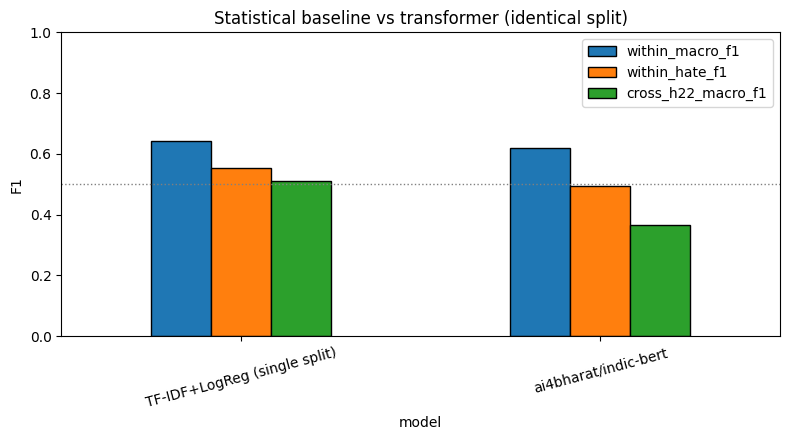

saved model_comparison.png and model_comparison.csv


In [16]:
BASELINE = {
    'model': 'TF-IDF+LogReg (single split)',
    'within_macro_f1': 0.642,
    'within_hate_f1':  0.555,
    'within_f1_not':   0.729,
    'cross_h22_macro_f1': 0.510,
}
comparison = pd.DataFrame([
    BASELINE,
    {'model': MODEL_NAME,
     'within_macro_f1': res['macro_f1'], 'within_hate_f1': res['hate_f1'],
     'within_f1_not': res['f1_not'], 'cross_h22_macro_f1': cross_macro},
]).round(3)
display(comparison)
comparison.to_csv(W / 'model_comparison.csv', index=False)

ax = comparison.set_index('model')[['within_macro_f1','within_hate_f1','cross_h22_macro_f1']].plot(
    kind='bar', figsize=(8,4.5), edgecolor='black', rot=15)
ax.set_ylabel('F1'); ax.set_ylim(0,1); ax.axhline(0.5, color='grey', ls=':', lw=1)
ax.set_title('Statistical baseline vs transformer (identical split)')
plt.tight_layout(); plt.savefig(FIG_DIR / 'model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved model_comparison.png and model_comparison.csv')

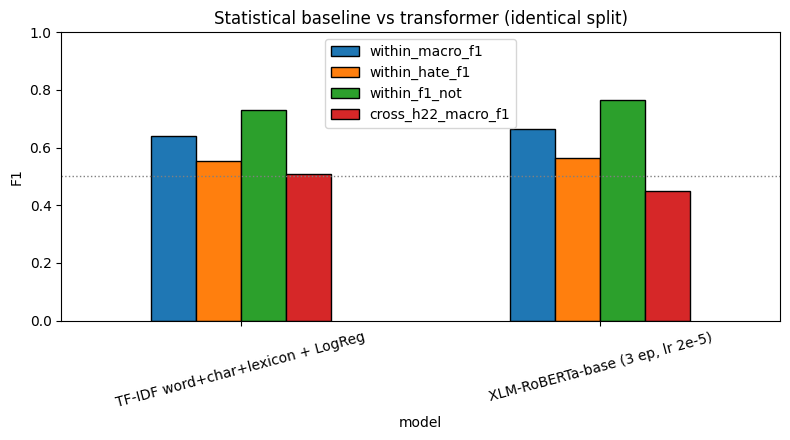

In [17]:
import pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
W = Path('/content/drive/MyDrive/dissertation/writing')
comparison = pd.DataFrame([
    {'model':'TF-IDF word+char+lexicon + LogReg','within_macro_f1':0.642,
     'within_hate_f1':0.555,'within_f1_not':0.729,'cross_h22_macro_f1':0.510},
    {'model':'XLM-RoBERTa-base (3 ep, lr 2e-5)','within_macro_f1':0.665,
     'within_hate_f1':0.565,'within_f1_not':0.764,'cross_h22_macro_f1':0.448},
])
comparison.to_csv(W/'model_comparison.csv', index=False)
ax = comparison.set_index('model').plot(kind='bar', figsize=(8,4.5), edgecolor='black', rot=15)
ax.set_ylabel('F1'); ax.set_ylim(0,1); ax.axhline(0.5, color='grey', ls=':', lw=1)
ax.set_title('Statistical baseline vs transformer (identical split)')
plt.tight_layout(); plt.savefig(W/'figures/model_comparison.png', dpi=150, bbox_inches='tight'); plt.show()

### 12. Next model

To add MuRIL: set `MODEL_NAME = 'google/muril-base-cased'` in section 3 and re-run from
section 3 down. Results append to `transformer_results.csv` automatically, so nothing is
overwritten.

MuRIL is the one to expect most from, because it is pretrained on transliterated Roman-script
Indian-language text, which is exactly the input this project handles.

**Still outstanding after this notebook:**
- 5-fold CV on the transformer (this is a single split; the baseline headline is 5-fold)
- IndicBERT and the LoRA LLM
- The romanisation-variant attack from `variants.py`